In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
df = df[df["RegionName"] == "Cleveland, OH"]
df.shape

(1, 323)

In [3]:
zip_df = pd.read_csv("../data/Zip_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
zip_df[zip_df["RegionName"].isin(["44111", "44135"])].head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2000-01-31,...,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31,2026-06-30


In [4]:
zip_df[zip_df["City"] == "Cleveland"]["RegionName"].unique()

array([44102, 44111, 44109, 44105, 37312, 37311, 37323, 77327, 44135,
       30528, 44106, 44108, 77328, 44104, 44113, 44110, 38732, 44103,
       44119, 44115, 44114, 27013, 74020, 44127, 35049, 13042, 64734,
       29635, 56017])

In [5]:
zip_df[zip_df["RegionName"].isin([44111, 44135])].head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2000-01-31,...,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31,2026-06-30
1755,77011,1780,44111,zip,OH,OH,Cleveland,"Cleveland-Elyria, OH",Cuyahoga County,89010.004839,...,164540.610366,164304.594996,164548.902476,165117.757750,165739.510730,166350.714290,166567.609459,166211.232501,165734.230669,165420.857960
4217,77035,4266,44135,zip,OH,OH,Cleveland,"Cleveland-Elyria, OH",Cuyahoga County,72577.243580,...,157576.425885,158298.840142,159154.044467,160093.953471,160967.230729,161763.814507,162254.029306,162570.328677,162694.059229,162887.097831


In [8]:
zips = [44111, 44135]
zip_data = zip_df[zip_df["RegionName"].isin(zips)]

# Keep only the ID columns and the date columns
date_cols = [col for col in zip_data.columns if col not in ["RegionID", "RegionName", "City", "Metro", "CountyName", "SizeRank", "RegionType", "StateName", "State", "CountyName"]]
zip_data_clean = zip_data[["RegionID", "RegionName", "City", "Metro"] + date_cols]

zip_long = zip_data_clean.melt(
    id_vars=["RegionID", "RegionName", "City", "Metro"],
    var_name="date",
    value_name="home_value"
)

zip_long["date"] = pd.to_datetime(zip_long["date"])
zip_long = zip_long[zip_long["date"] >= "2015-01-01"]
zip_long.shape

(276, 6)

In [10]:
metro_cleveland = pd.read_csv("../data/Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
metro_cleveland = metro_cleveland[metro_cleveland["RegionName"] == "Cleveland, OH"]

# Get only date columns
date_cols_metro = [col for col in metro_cleveland.columns if col not in ["RegionID", "RegionName", "RegionType", "StateName", "SizeRank"]]
metro_cleveland = metro_cleveland[["RegionName"] + date_cols_metro]

metro_long = metro_cleveland.melt(
    id_vars=["RegionName"],
    var_name="date",
    value_name="home_value"
)

metro_long["date"] = pd.to_datetime(metro_long["date"])
metro_long = metro_long[metro_long["date"] >= "2015-01-01"]
metro_long["RegionName"] = "Cleveland Metro (Avg)"

combined = pd.concat([
    zip_long[["RegionName", "date", "home_value"]],
    metro_long[["RegionName", "date", "home_value"]]
])

combined.shape

(414, 3)

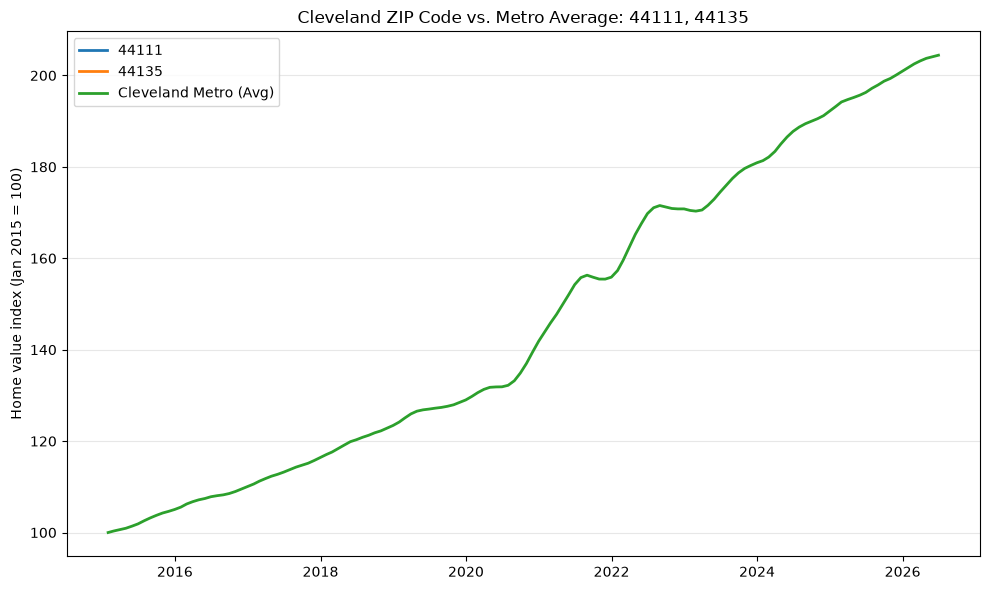

In [11]:
combined["indexed"] = combined.groupby("RegionName")["home_value"].transform(lambda x: x / x.iloc[0] * 100)

plt.figure(figsize=(10, 6))

for name in ["44111", "44135", "Cleveland Metro (Avg)"]:
    data = combined[combined["RegionName"] == name]
    plt.plot(data["date"], data["indexed"], label=name, linewidth=2)

plt.legend()
plt.ylabel("Home value index (Jan 2015 = 100)")
plt.title("Cleveland ZIP Code vs. Metro Average: 44111, 44135")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
latest = combined[combined["date"] == combined["date"].max()]
latest[["RegionName", "home_value", "indexed"]].sort_values("home_value", ascending=False)

,RegionName,home_value,indexed
317,Cleveland Metro (Avg),255598.498594,204.429307
634,44111,165420.857960,230.549588
635,44135,162887.097831,262.839859


In [14]:
combined["RegionName"].unique()

array([44111, 44135, 'Cleveland Metro (Avg)'], dtype=object)

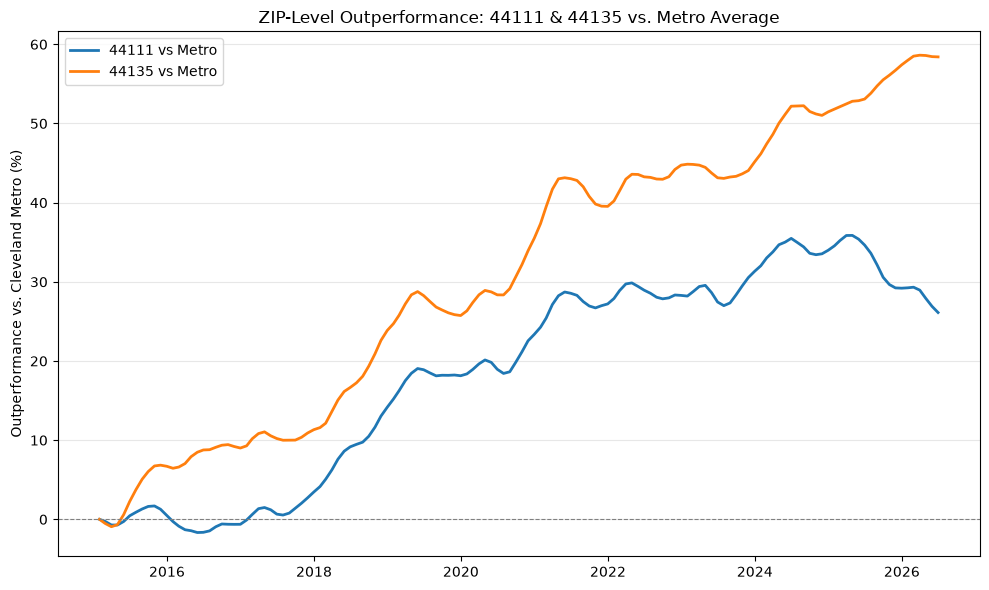

In [18]:
pivot = combined.pivot(index="date", columns="RegionName", values="indexed")

pivot["44111 vs Metro"] = pivot[44111] - pivot["Cleveland Metro (Avg)"]
pivot["44135 vs Metro"] = pivot[44135] - pivot["Cleveland Metro (Avg)"]

plt.figure(figsize=(10, 6))
plt.plot(pivot.index, pivot["44111 vs Metro"], label="44111 vs Metro", linewidth=2)
plt.plot(pivot.index, pivot["44135 vs Metro"], label="44135 vs Metro", linewidth=2)
plt.axhline(0, color="grey", linestyle="--", linewidth=0.8)

plt.ylabel("Outperformance vs. Cleveland Metro (%)")
plt.title("ZIP-Level Outperformance: 44111 & 44135 vs. Metro Average")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
plt.savefig("../charts/cleveland_zip_outperformance.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

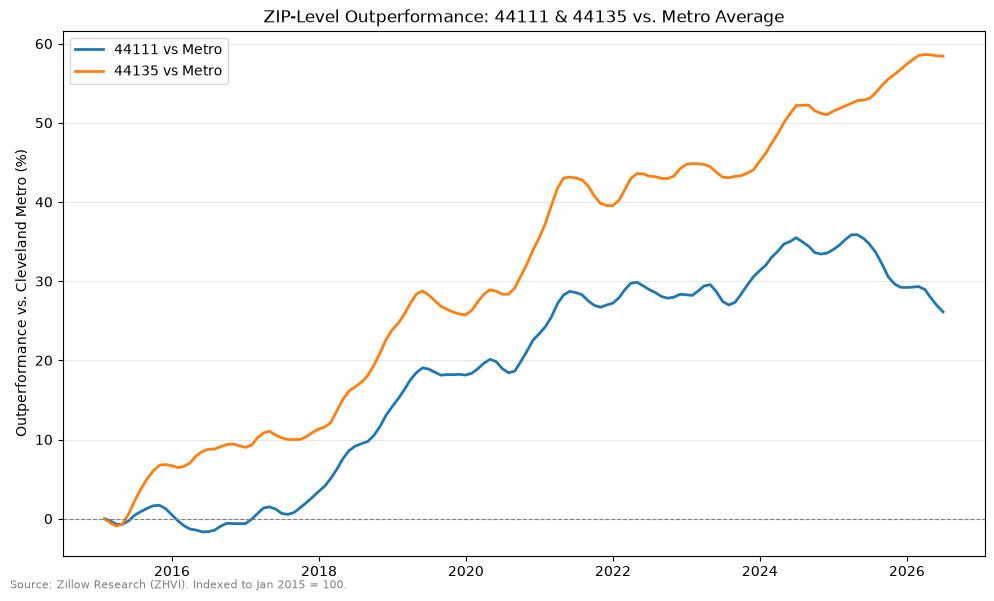

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(pivot.index, pivot["44111 vs Metro"], label="44111 vs Metro", linewidth=2)
plt.plot(pivot.index, pivot["44135 vs Metro"], label="44135 vs Metro", linewidth=2)
plt.axhline(0, color="grey", linestyle="--", linewidth=0.8)

plt.ylabel("Outperformance vs. Cleveland Metro (%)")
plt.title("ZIP-Level Outperformance: 44111 & 44135 vs. Metro Average")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.figtext(0.01, 0.01, "Source: Zillow Research (ZHVI). Indexed to Jan 2015 = 100.", fontsize=8, color="grey")

plt.tight_layout()
plt.savefig("../charts/cleveland_zip_outperformance.png", dpi=150, bbox_inches="tight")
plt.show()